In [48]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sbn 
import torch 
from sklearn.neighbors  import kneighbors_graph
import networkx as nx 
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.nonparametric import kaplan_meier_estimator

In [3]:
vae = pd.read_csv('/home/teddy/local/AMLVAE/workflows/folds/mds_fpkm_wgcna_zscore_2000_latent32/consensus/vae_consensus_matrix.csv')
pca = pd.read_csv('/home/teddy/local/AMLVAE/workflows/folds/mds_fpkm_wgcna_zscore_2000_latent32/consensus/pca_consensus_matrix.csv')

vae =  vae.set_index('Unnamed: 0')
pca =  pca.set_index('Unnamed: 0')


In [4]:
ids = vae.columns.values 
upper_tri_ixs = np.triu_indices(len(ids), k=1) 
vae_flat = vae.loc[ids, ids].values[upper_tri_ixs] 
pca_flat = pca.loc[ids, ids].values[upper_tri_ixs] 

np.corrcoef(vae_flat, pca_flat)[0,1]

np.float64(0.7160306844697888)

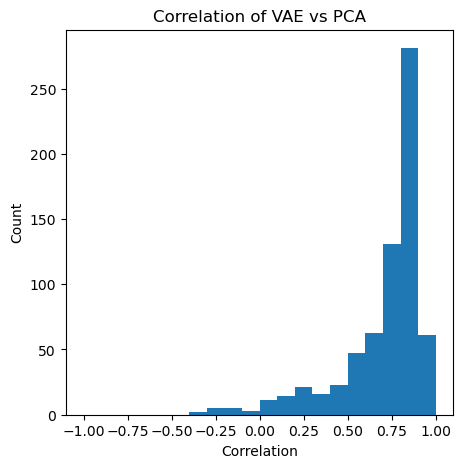

In [5]:
corr_row = {'id': [], 'corr': []}
for id in ids:
    corr_row['id'].append(id)
    corr_row['corr'].append(np.corrcoef(vae.loc[id], pca.loc[id])[0,1])

corr_row = pd.DataFrame(corr_row)
corr_row = corr_row.set_index('id')

plt.figure(figsize=(5,5)) 
plt.hist(corr_row['corr'], bins=np.arange(-1,1.1,0.1)) 
plt.xlabel('Correlation') 
plt.ylabel('Count') 
plt.title('Correlation of VAE vs PCA') 
plt.show() 

/home/teddy/miniconda3/envs/amlvae/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/teddy/miniconda3/envs/amlvae/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


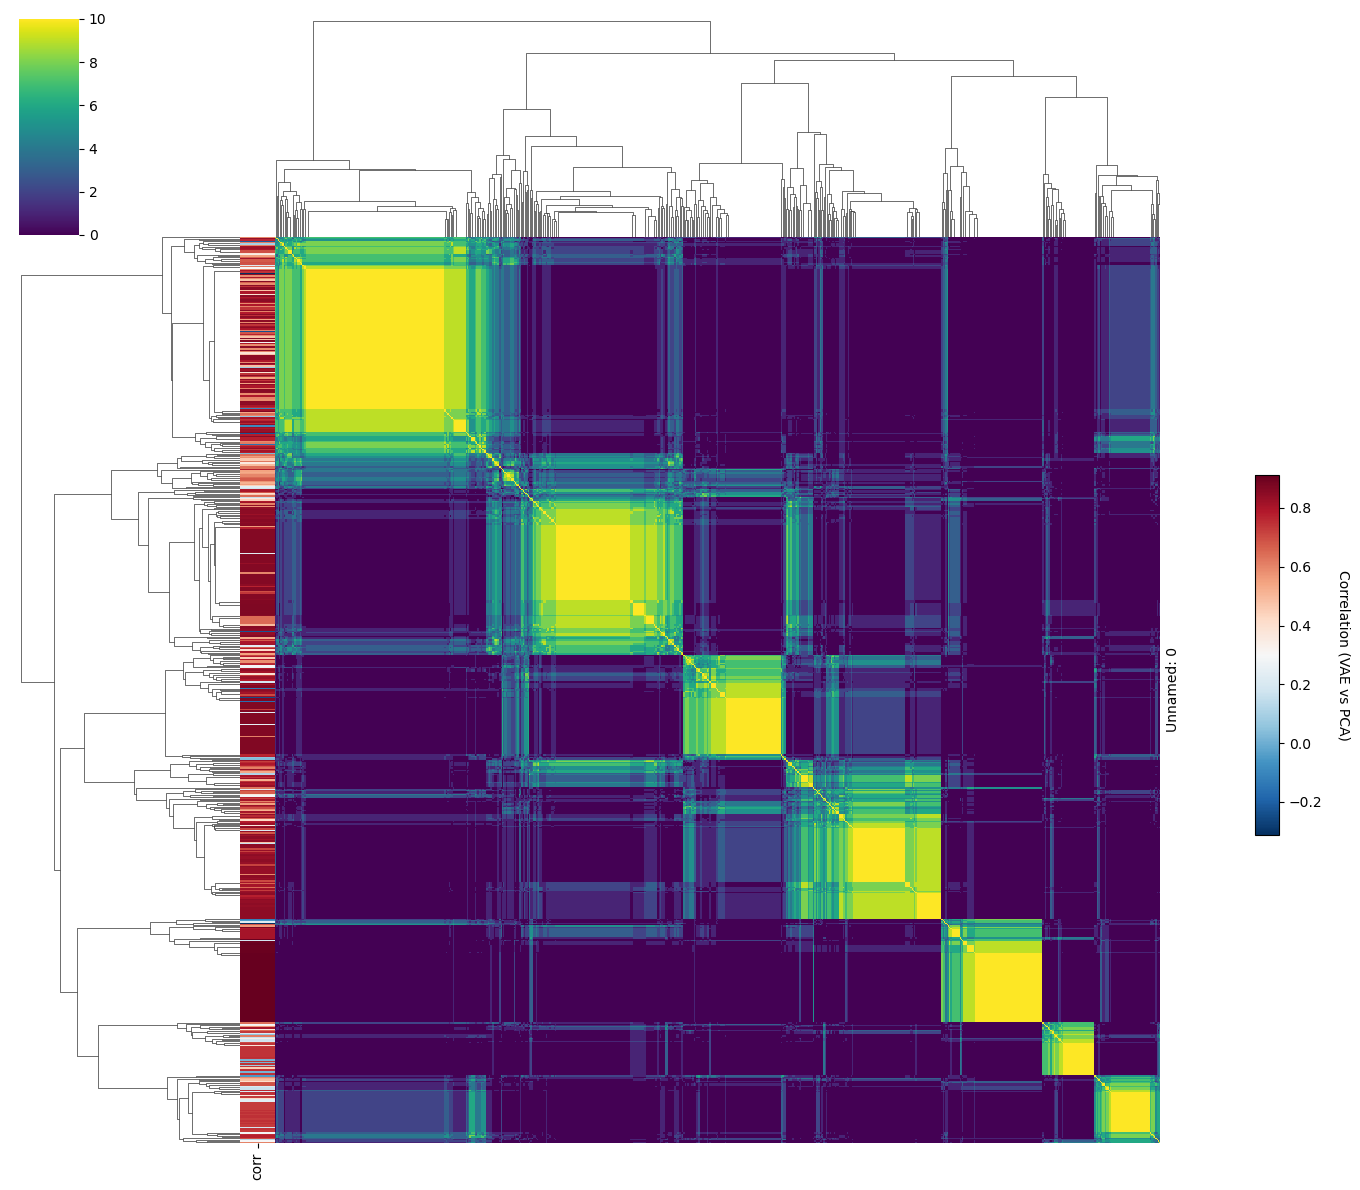

In [6]:


# make row colors continuous using a colormap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Create a colormap for the correlation values (continuous)
norm = Normalize(vmin=corr_row['corr'].min(), vmax=corr_row['corr'].max())
cmap_colors = plt.cm.RdBu_r  # Red for low correlation, Blue for high correlation
sm = ScalarMappable(cmap=cmap_colors, norm=norm)
row_colors_continuous = corr_row['corr'].map(lambda x: sm.to_rgba(x))

# Create clustermap with continuous row colors and no axis labels
g = sbn.clustermap(vae, cmap='viridis', vmin=0, vmax=10, 
                   row_colors=row_colors_continuous,
                   xticklabels=False, yticklabels=False,
                   figsize=(12, 12))

# Add a colorbar for the row colors to show correlation scale
cbar_ax = g.fig.add_axes([1.05, 0.3, 0.02, 0.3])  # [left, bottom, width, height]
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Correlation (VAE vs PCA)', rotation=270, labelpad=20)

plt.show()


In [7]:

# create a knn graph using co-occurence matrix
def knn(mat, ids, nn=15, directed=False, self_edges=False): 

    mat = mat.loc[ids, ids].values

    edges = [] 
    for i in range(mat.shape[0]): 
        # get the top nn neighbors 
        top_nn = np.argsort(mat[i])[::-1][:nn]
        for j in top_nn: 
            edges.append((ids[i], ids[j], {'weight': mat[i,j]})) 

    # create a graph from the edges 
    G = nx.DiGraph() if directed else nx.Graph() 
    G.add_edges_from(edges) 

    if not self_edges: 
        G.remove_edges_from(nx.selfloop_edges(G))

    return G 
            
            

In [8]:
nn = 15
directed = True

G_vae = knn(vae, ids, nn=nn, directed=directed) 
G_pca = knn(pca, ids, nn=nn, directed=directed) 

print('VAE:')
print('\t density: ', nx.density(G_vae))
print('\t average degree: ', np.mean(list(dict(G_vae.degree()).values())))
print('\t average clustering coefficient: ', nx.average_clustering(G_vae))
if directed: 
    print('\t # connected components: ', nx.number_weakly_connected_components(G_vae))
else: 
    print('\t # connected components: ', nx.number_connected_components(G_vae))

print('PCA:')
print('\t density: ', nx.density(G_pca))
print('\t average degree: ', np.mean(list(dict(G_pca.degree()).values())))
print('\t average clustering coefficient: ', nx.average_clustering(G_pca))
if directed: 
    print('\t # connected components: ', nx.number_weakly_connected_components(G_pca))
else: 
    print('\t # connected components: ', nx.number_connected_components(G_pca))


VAE:
	 density:  0.021064563358994946
	 average degree:  28.732064421669108
	 average clustering coefficient:  0.5485051182014858
	 # connected components:  1
PCA:
	 density:  0.021010892946849116
	 average degree:  28.658857979502198
	 average clustering coefficient:  0.6939488107589108
	 # connected components:  2


In [9]:
resolution = 1

vae_comm = nx.community.louvain_communities(G_vae, resolution=resolution, weight='weight') 
pca_comm = nx.community.louvain_communities(G_pca, resolution=resolution, weight='weight') 

print('VAE:')
print('\t # communities: ', len(vae_comm))

print('PCA:')
print('\t # communities: ', len(pca_comm))

VAE:
	 # communities:  9
PCA:
	 # communities:  14


In [10]:
# community colors for nx draw nodes 
def community_colors(G, communities):
    """
    Create node colors based on community membership.
    
    Parameters:
    -----------
    G : networkx.Graph
        The graph containing the nodes
    communities : list of sets
        List of communities (sets of nodes)
        
    Returns:
    --------
    list
        List of colors for each node in G
    """
    n_communities = len(communities)
    cmap = plt.colormaps['tab20' if n_communities <= 20 else 'hsv']
    
    # Map each node to its community index
    node_to_comm = {}
    for comm_idx, community in enumerate(communities):
        for node in community:
            node_to_comm[node] = comm_idx
    
    # Create color list for all nodes in the graph
    colors = [cmap(node_to_comm.get(node, 0) / n_communities) for node in G.nodes()]
    return colors

# Generate colors for VAE and PCA communities
vae_comm_colors = community_colors(G_vae, vae_comm)
pca_comm_colors = community_colors(G_pca, pca_comm)

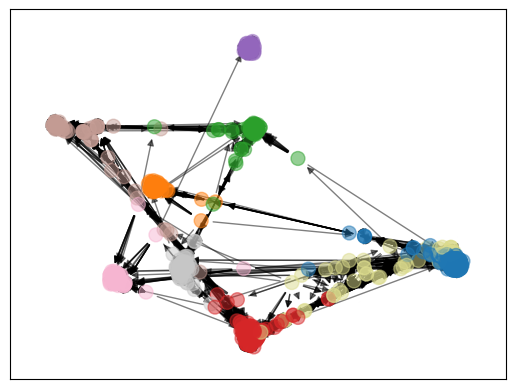

In [11]:
plt.figure() 
pos = nx.spring_layout(G_vae) 

nx.draw_networkx_nodes(G_vae, pos, node_color=vae_comm_colors, node_size=100, alpha=0.5) 
nx.draw_networkx_edges(G_vae, pos, alpha=0.5)
 
plt.show() 

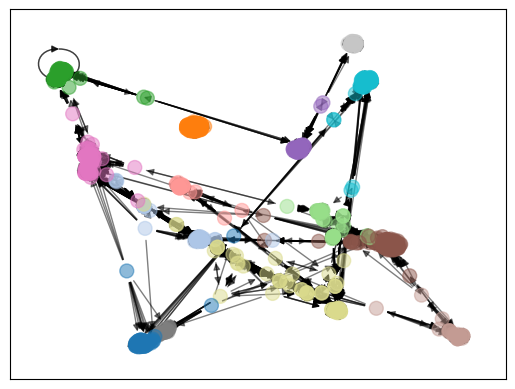

In [12]:
plt.figure() 
pos = nx.spring_layout(G_pca) 

nx.draw_networkx_nodes(G_pca, pos, node_color=pca_comm_colors, node_size=100, alpha=0.5) 
nx.draw_networkx_edges(G_pca, pos, alpha=0.5)
 
plt.show() 

In [13]:

def comm2df(comm): 

    df = {'id': [], 'comm': []}
    for i, c in enumerate(comm): 
        for id in c: 
            df['id'].append(id) 
            df['comm'].append(i) 

    identity = np.eye(len(comm)) 
    comm2onehot = {i: identity[i] for i in range(len(comm))}
    df = pd.DataFrame(df) 
    df['x'] = df['comm'].map(comm2onehot) 
    return df

pca_comm_df = comm2df(pca_comm) 
vae_comm_df = comm2df(vae_comm) 

pca_comm_df.head() 

,id,comm,x
0,MLL_15881,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,MLL_27228,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,MLL_15876,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,MLL_11427,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,MUC_00041,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [36]:
clin = pd.read_csv('/home/teddy/local/data/evansmds/805_data_20250107.csv') 
clin = clin.assign(vitalStatus = lambda x: x['Date of Death'].notna()) 
clin['vitalStatus'].value_counts()

vitalStatus
True     493
False    181
Name: count, dtype: int64

In [32]:
pca_comm_df = pca_comm_df.merge(clin[['MLL ID', 'vitalStatus', 'Overall survival (days)']], left_on='id', right_on='MLL ID', how='left')  
vae_comm_df = vae_comm_df.merge(clin[['MLL ID', 'vitalStatus', 'Overall survival (days)']], left_on='id', right_on='MLL ID', how='left')  

In [37]:
pca_comm_df.head() 

,id,comm,x,MLL ID,vitalStatus,Overall survival (days)
0,MLL_15881,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",MLL_15881,False,1834.0
1,MLL_27228,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",MLL_27228,True,773.0
2,MLL_15876,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",MLL_15876,True,1513.0
3,MLL_11427,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",MLL_11427,True,1453.0
4,MUC_00041,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",MUC_00041,True,1227.0


In [38]:
alphas = [1e-4]

pca_comm_df2 = pca_comm_df[lambda x: x.vitalStatus.notna()]

data_x_numeric = pd.DataFrame(np.vstack(pca_comm_df2.x.values))# + np.random.normal(0, 0.01, size=data_x_numeric.shape)

data_y = pca_comm_df2[['vitalStatus', 'Overall survival (days)']]
data_y.loc[:, 'vitalStatus'] = data_y['vitalStatus']
data_y = np.array(
    [(data_y['vitalStatus'].values[i], data_y['Overall survival (days)'].values[i].astype(float)) for i in range(data_y.shape[0])], 
    dtype=[('vitalStatus', 'bool'), ('Overall survival (days)', 'float')]
)


estimator = CoxnetSurvivalAnalysis(alphas = alphas)
estimator.fit(data_x_numeric, data_y)


pca_coefs = estimator.coef_

In [41]:
vae_comm_df2 = vae_comm_df[lambda x: x.vitalStatus.notna()]


data_x_numeric = pd.DataFrame(np.vstack(vae_comm_df2.x.values))# + np.random.normal(0, 0.01, size=data_x_numeric.shape)

data_y = vae_comm_df2[['vitalStatus', 'Overall survival (days)']]
data_y.loc[:, 'vitalStatus'] = data_y['vitalStatus']
data_y = np.array(
    [(data_y['vitalStatus'].values[i], data_y['Overall survival (days)'].values[i].astype(float)) for i in range(data_y.shape[0])], 
    dtype=[('vitalStatus', 'bool'), ('Overall survival (days)', 'float')]
)


estimator = CoxnetSurvivalAnalysis(alphas = alphas)
estimator.fit(data_x_numeric, data_y)


vae_coefs = estimator.coef_


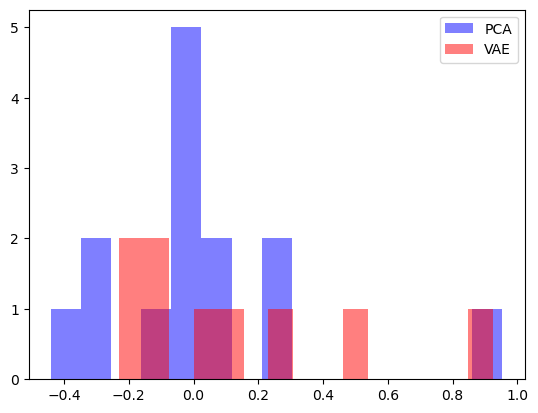

In [42]:
plt.figure() 
plt.hist(pca_coefs, color='blue', alpha=0.5, label='PCA', bins=15) 
plt.hist(vae_coefs, color='red', alpha=0.5, label='VAE', bins=15) 
plt.legend() 
plt.show() 





In [43]:
from sksurv.compare import compare_survival 

vae_pvals = {}
for i in range(len(vae_comm)): 
    vae_comm_df2 = vae_comm_df[lambda x: x.vitalStatus.notna()]

    # Prepare survival data
    data_y = vae_comm_df2[['vitalStatus', 'Overall survival (days)']]
    data_y.loc[:, 'vitalStatus'] = data_y['vitalStatus']
    data_y = np.array(
        [(data_y['vitalStatus'].values[i], data_y['Overall survival (days)'].values[i].astype(float)) for i in range(data_y.shape[0])], 
        dtype=[('vitalStatus', 'bool'), ('Overall survival (days)', 'float')]
    )

    # Use community assignments as groups
    group_indicator = np.vstack(vae_comm_df2['x'].values)[:, i]

    if group_indicator.sum() < 1: continue 

    # Perform log-rank test to compare survival across communities
    chi_stat, p_value = compare_survival(data_y, group_indicator)

    print(f"VAE Communities Survival Comparison:")
    print(f"  Chi-squared statistic: {chi_stat:.4f}")
    print(f"  P-value: {p_value:.4e}")
    print(f"  Number of communities: {len(np.unique(group_indicator))}")

    vae_pvals[i] = p_value 



VAE Communities Survival Comparison:
  Chi-squared statistic: 7.9805
  P-value: 4.7284e-03
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 10.2926
  P-value: 1.3356e-03
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 2.3330
  P-value: 1.2665e-01
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 0.0433
  P-value: 8.3508e-01
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 28.2715
  P-value: 1.0544e-07
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 2.2871
  P-value: 1.3045e-01
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 0.5948
  P-value: 4.4058e-01
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared statistic: 0.6172
  P-value: 4.3210e-01
  Number of communities: 2
VAE Communities Survival Comparison:
  Chi-squared sta

In [44]:
pca_pvals = {}

for i in range(len(pca_comm)): 
    # Also compare PCA communities for comparison
    pca_comm_df2 = pca_comm_df[lambda x: x.vitalStatus.notna()]

    data_y_pca = pca_comm_df2[['vitalStatus', 'Overall survival (days)']]
    data_y_pca.loc[:, 'vitalStatus'] = data_y_pca['vitalStatus']
    data_y_pca = np.array(
        [(data_y_pca['vitalStatus'].values[i], data_y_pca['Overall survival (days)'].values[i].astype(float)) for i in range(data_y_pca.shape[0])], 
        dtype=[('vitalStatus', 'bool'), ('Overall survival (days)', 'float')]
    )

    group_indicator_pca = np.vstack(pca_comm_df2['x'].values)[:, i]

    if group_indicator_pca.sum() < 1: continue 

    chi_stat_pca, p_value_pca = compare_survival(data_y_pca, group_indicator_pca)

    print(f"\nPCA Communities Survival Comparison:")
    print(f"  Chi-squared statistic: {chi_stat_pca:.4f}")
    print(f"  P-value: {p_value_pca:.4e}")
    print(f"  Number of communities: {len(np.unique(group_indicator_pca))}")

    pca_pvals[i] = p_value_pca 


PCA Communities Survival Comparison:
  Chi-squared statistic: 0.0501
  P-value: 8.2281e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 0.0208
  P-value: 8.8520e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 0.0085
  P-value: 9.2675e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 6.6685
  P-value: 9.8131e-03
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 1.6710
  P-value: 1.9613e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 1.1182
  P-value: 2.9031e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 0.0138
  P-value: 9.0664e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squared statistic: 0.1388
  P-value: 7.0952e-01
  Number of communities: 2

PCA Communities Survival Comparison:
  Chi-squa

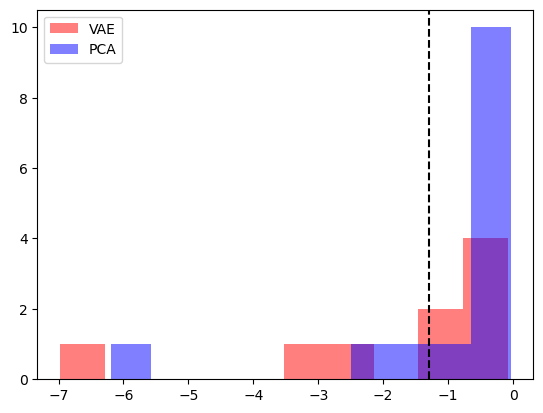

VAE: 3 significant communities
PCA: 3 significant communities


In [45]:
plt.figure() 
plt.hist(np.log10(list(vae_pvals.values())), alpha=0.5, label='VAE', color='red')
plt.hist(np.log10(list(pca_pvals.values())), alpha=0.5, label='PCA', color='blue')
plt.axvline(np.log10(0.05), color='black', linestyle='--')
plt.legend() 
plt.show() 

n_sig_vae = sum(np.log10(list(vae_pvals.values())) < np.log10(0.05))
n_sig_pca = sum(np.log10(list(pca_pvals.values())) < np.log10(0.05))

print(f'VAE: {n_sig_vae} significant communities')
print(f'PCA: {n_sig_pca} significant communities')



In [47]:
vae_comm_df2 = vae_comm_df[lambda x: x.vitalStatus.notna()]

# Prepare survival data
data_y = vae_comm_df2[['vitalStatus', 'Overall survival (days)']]
data_y.loc[:, 'vitalStatus'] = data_y['vitalStatus']
data_y = np.array(
    [(data_y['vitalStatus'].values[i], data_y['Overall survival (days)'].values[i].astype(float)) for i in range(data_y.shape[0])], 
    dtype=[('vitalStatus', 'bool'), ('Overall survival (days)', 'float')]
)

# Use community assignments as groups
group_indicator = vae_comm_df2['comm'].values

# Perform log-rank test to compare survival across communities
chi_stat, p_value = compare_survival(data_y, group_indicator)

print(f"VAE Communities Survival Comparison:")
print(f"  Chi-squared statistic: {chi_stat:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Number of communities: {len(np.unique(group_indicator))}")


VAE Communities Survival Comparison:
  Chi-squared statistic: 49.6536
  P-value: 4.7635e-08
  Number of communities: 9


In [ ]:

# Also compare PCA communities for comparison
pca_comm_df2 = pca_comm_df[lambda x: x.vitalStatus.notna()]

data_y_pca = pca_comm_df2[['vitalStatus', 'overallSurvival']]
data_y_pca.loc[:, 'vitalStatus'] = data_y_pca['vitalStatus'] == 'Alive'
data_y_pca = np.array(
    [(data_y_pca['vitalStatus'].values[i], data_y_pca['overallSurvival'].values[i].astype(float)) for i in range(data_y_pca.shape[0])], 
    dtype=[('vitalStatus', 'bool'), ('overallSurvival', 'float')]
)

group_indicator_pca = pca_comm_df2['comm'].values
chi_stat_pca, p_value_pca = compare_survival(data_y_pca, group_indicator_pca)

print(f"\nPCA Communities Survival Comparison:")
print(f"  Chi-squared statistic: {chi_stat_pca:.4f}")
print(f"  P-value: {p_value_pca:.4e}")
print(f"  Number of communities: {len(np.unique(group_indicator_pca))}")


PCA Communities Survival Comparison:
  Chi-squared statistic: 27.9122
  P-value: 1.4615e-02
  Number of communities: 15


Text(0.5, 0, 'time $t$')

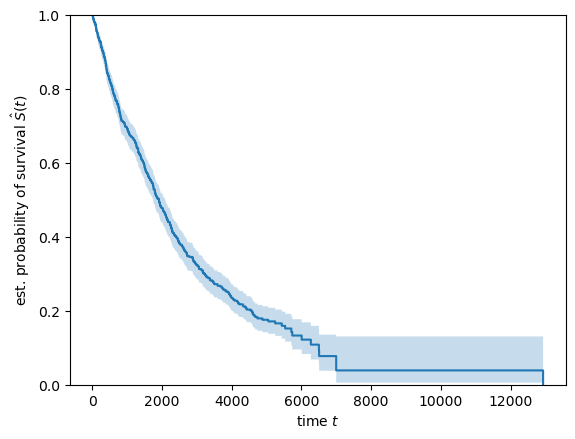

In [50]:
time, survival_prob, conf_int = kaplan_meier_estimator(
    clin["vitalStatus"], clin["Overall survival (days)"], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

In [61]:
pca_comm_df = comm2df(pca_comm) 
vae_comm_df = comm2df(vae_comm) 

pca_comm_df2 = pca_comm_df.merge(clin[['MLL ID', 'vitalStatus', 'Overall survival (days)']], left_on='id', right_on='MLL ID', how='left') 
vae_comm_df2 = vae_comm_df.merge(clin[['MLL ID', 'vitalStatus', 'Overall survival (days)']], left_on='id', right_on='MLL ID', how='left')  

In [64]:
def plot_km(df): 

    df = df[lambda x: x.vitalStatus.notna()]

    for treatment_type in df.comm.unique():
        mask_treat = df["comm"] == treatment_type
        vital_status = (df["vitalStatus"][mask_treat]).astype(bool)  # Convert to boolean
        overall_survival = df["Overall survival (days)"][mask_treat]#.fillna(0)

        if sum(mask_treat) < 5: 
            print(f'{treatment_type} has less than 10 samples')
            continue 
    
        if overall_survival.isna().any(): 
            print(f'{treatment_type} has {overall_survival.isna().sum()} missing values')
            continue 
        if vital_status.isna().any(): 
            print(f'{treatment_type} has {vital_status.isna().sum()} missing values')
            continue 

        time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
            vital_status,
            overall_survival,
            conf_type="log-log",
        )   

        plt.step(time_treatment, survival_prob_treatment, where="post", label=f"Treatment = {treatment_type} [n={sum(mask_treat)}]")
        plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.25, step="post")

    plt.ylim(0, 1)
    plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
    plt.xlabel("time $t$")
    plt.legend(loc="best", bbox_to_anchor=(1.05, 1))
    plt.show() 

    return conf_int 

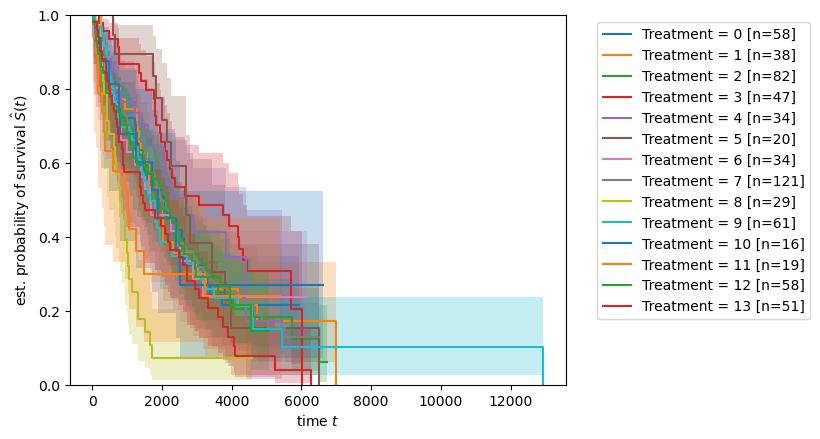

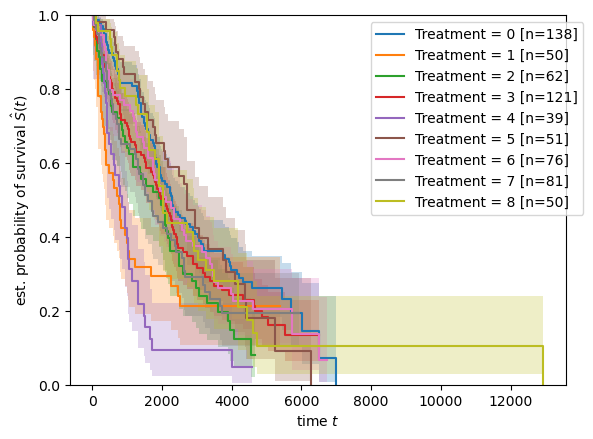

In [65]:
pca_conf = plot_km(pca_comm_df2) 
vae_conf = plot_km(vae_comm_df2) 